In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import seaborn as sns
import utils.base_utils as bu
import utils.window_utils as wu
import numpy as np
from utils.macro_grouping import add_group_level, build_full_group_mapping, groups_as_array

# Bianchi period:
start_date = '1971-08-31'
# end_date = '2018-12-31'

end_date = '2025-06-30' # kr and gsw end date
maturities = [str(i) for i in range(12, 121) if i % 12 == 0] # select only yearly maturities

yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=maturities) # type can be kr, lw, gsw
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=start_date, end=end_date) # this is aligned to the last day of the previous month, so we get the same number of observations as the yields data

monthly_yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness

# At time t (end of month), we only know data for month t-1
fred_md = fred_md_raw.shift(1)  

# Drop dates outside the xr range
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Backfill fred_md to avoid nans
fred_md = fred_md.bfill()

# Construct X with 3-level MultiIndex: (source, group, series)
s2g = build_full_group_mapping(fred_md, forward, yields)

X = pd.concat([fred_md, forward, yields],
               axis=1,
               keys=['fred', 'forward', 'yields'])

X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')
groups = groups_as_array(X, level='group')

y_all = xr[['24','36','48','60','72','84','96','108','120']].values
dates = xr.index

# Correlation between Macroeconomic variables

<Axes: >

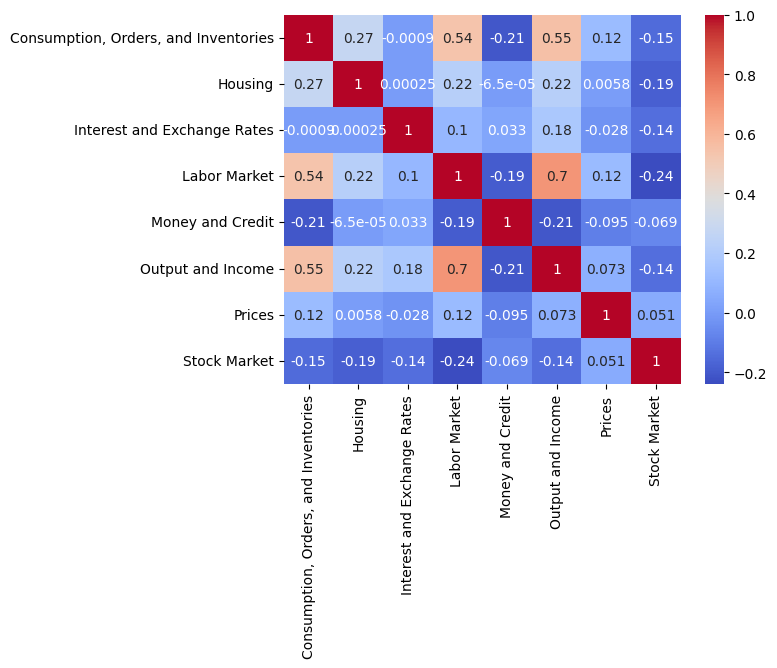

In [2]:
import numpy as np
import pandas as pd

# 1) Take FRED block only (columns are MultiIndex: [group, series])
fred = X["fred"].copy()

# Level with macro categories (usually level 0 after X['fred'])
group_level = 0

# Standardize each individual series over full sample (z-score by column, within each group block)
fred_std = fred.copy()
for g in fred.columns.get_level_values(group_level).unique():
    cols = fred.columns[fred.columns.get_level_values(group_level) == g]
    block = fred.loc[:, cols]
    mu = block.mean(axis=0)
    sd = block.std(axis=0, ddof=0).replace(0, np.nan)  # avoid divide-by-zero
    fred_std.loc[:, cols] = (block - mu) / sd

# Optional: fill constant-series NaNs with 0 after standardization
fred_std = fred_std.fillna(0.0)

# 2) Mean across standardized series within each macro group, per date
group_mean_df = pd.DataFrame({
    g: fred_std.loc[:, fred_std.columns.get_level_values(group_level) == g].mean(axis=1)
    for g in fred_std.columns.get_level_values(group_level).unique()
}, index=fred_std.index)

sns.heatmap(group_mean_df.corr(), annot=True, cmap='coolwarm')

Number of pairwise plots: 28


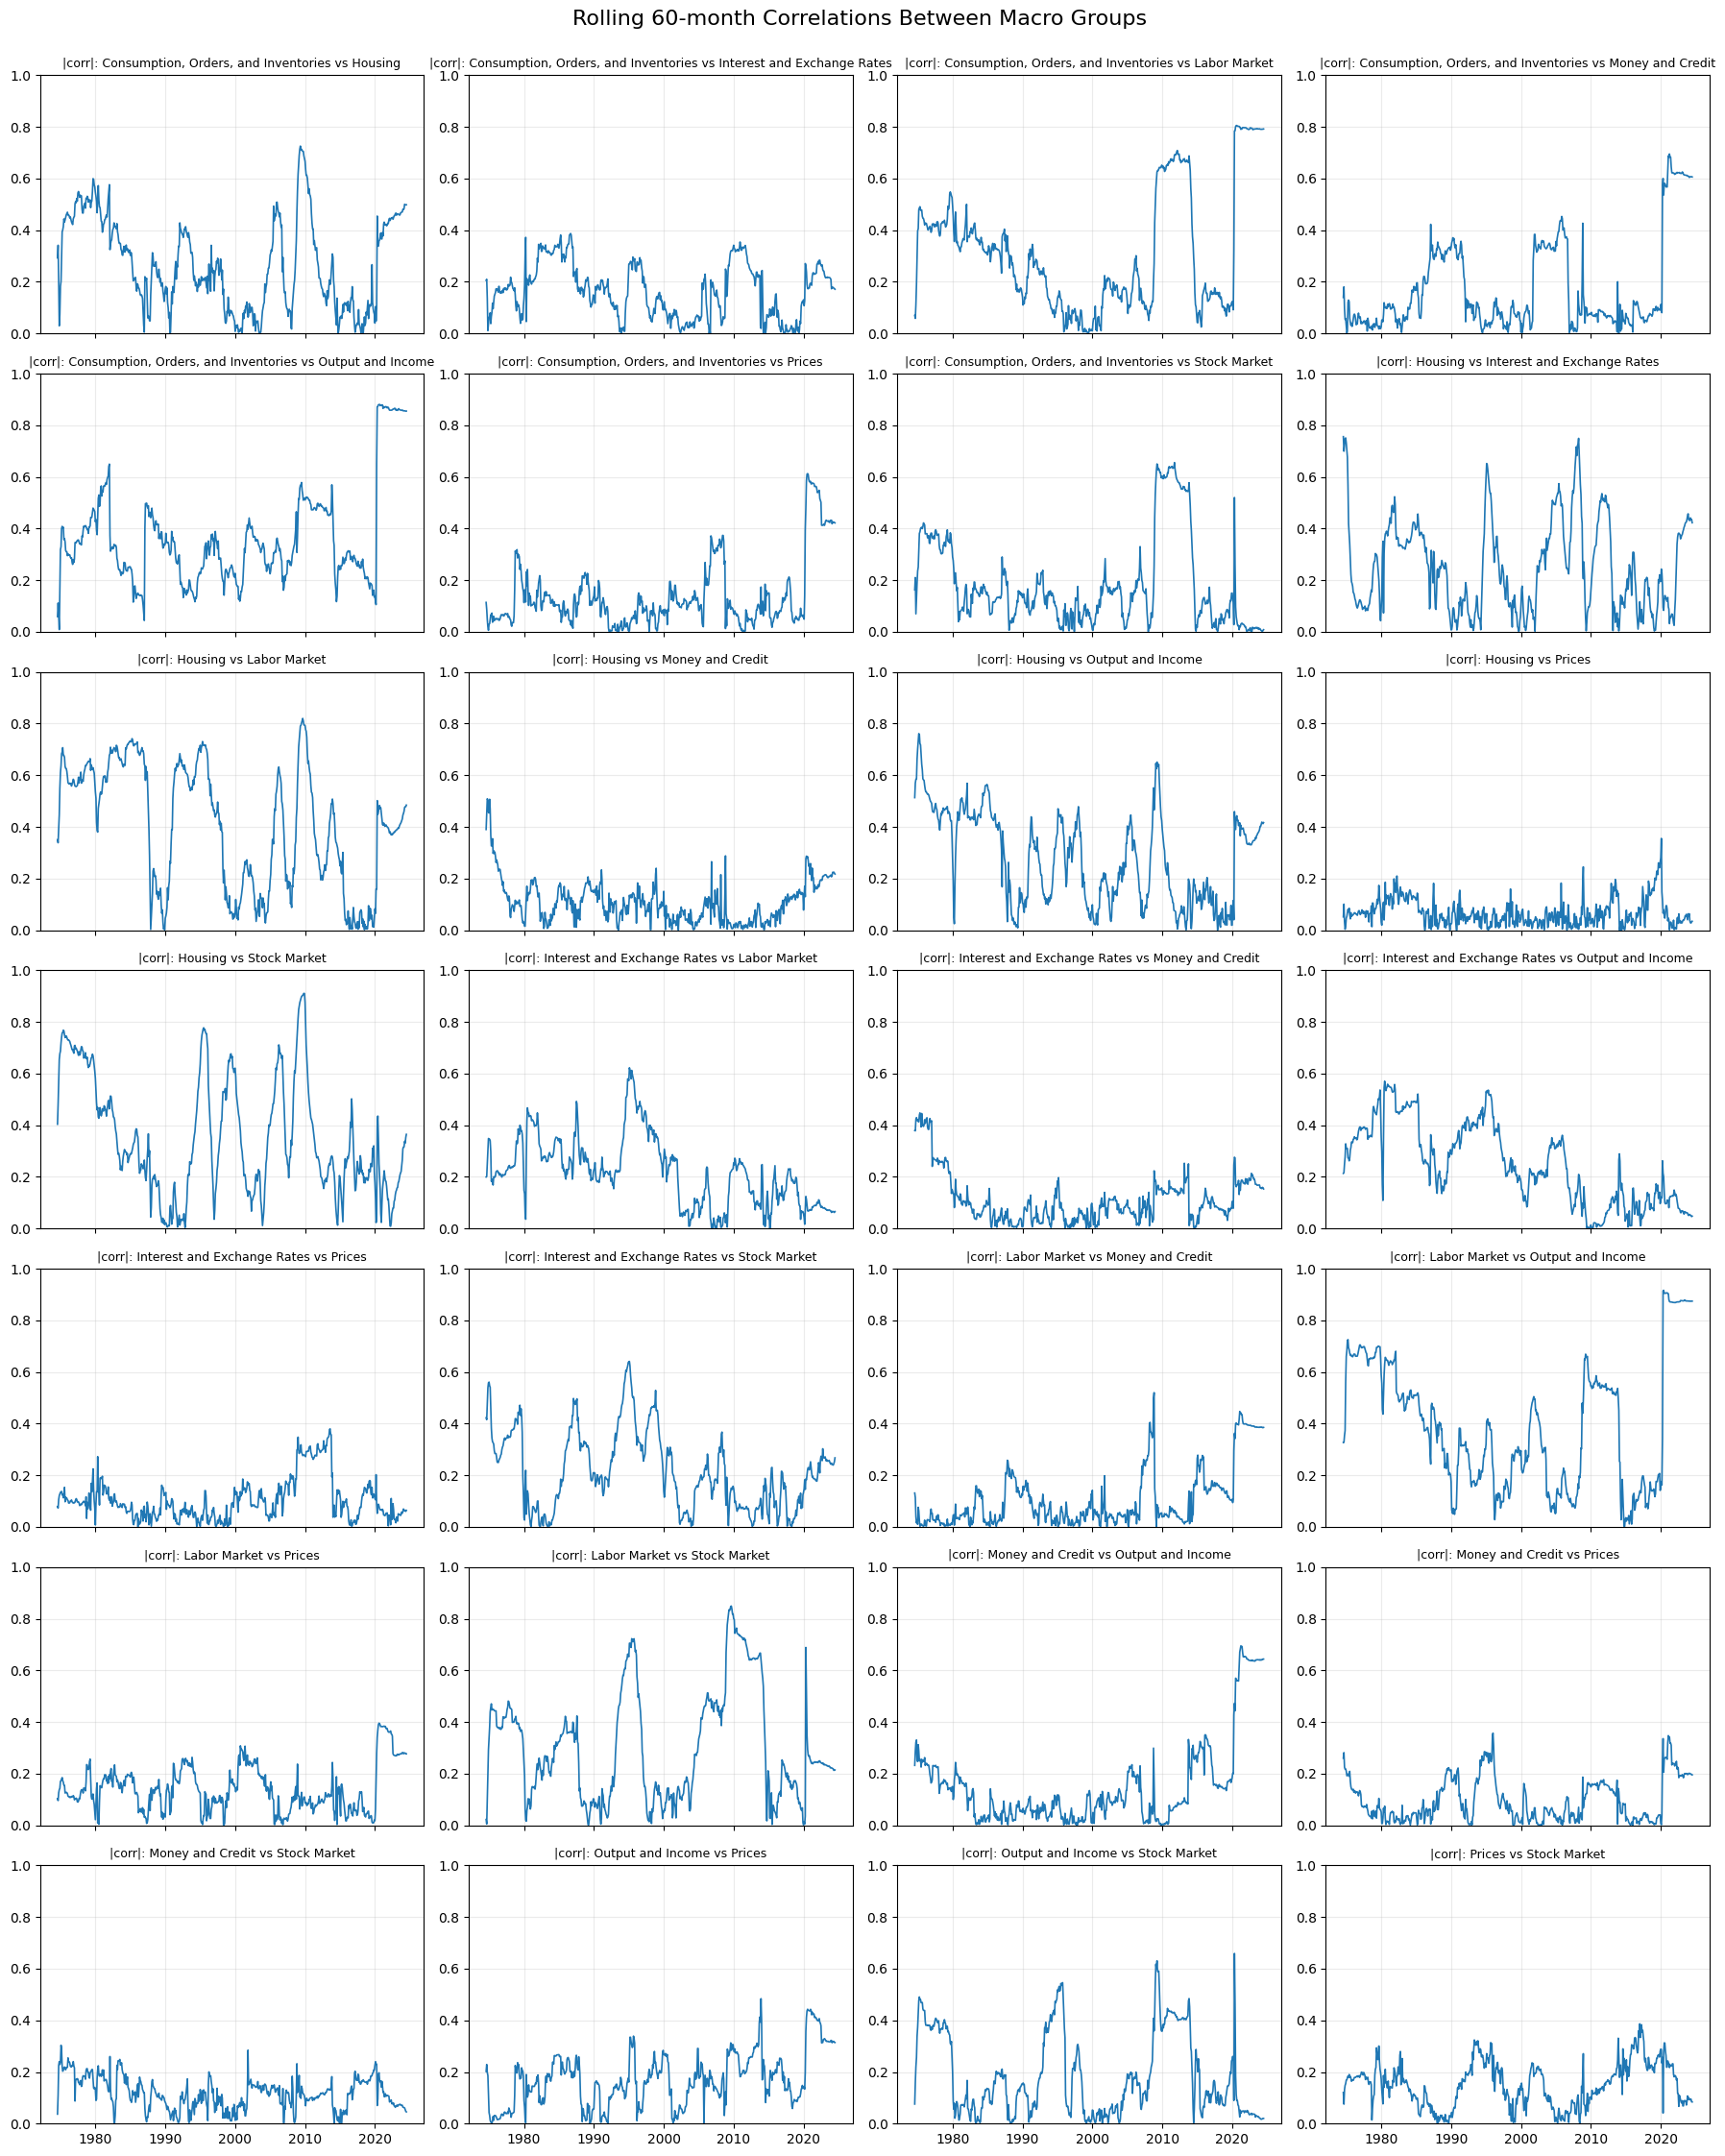

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

# group_mean_df: index=date, columns=8 grouped variables
window = 60  # 5 years of monthly data

pairs = list(combinations(group_mean_df.columns, 2))  # 28 pairs
n_plots = len(pairs)
print(f"Number of pairwise plots: {n_plots}")

# Make subplot grid (e.g., 7x4 for 28)
ncols = 4
nrows = int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.2 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, (a, b) in enumerate(pairs):
    corr_series = group_mean_df[a].rolling(window=window, min_periods=36).corr(group_mean_df[b]).abs()
    axes[i].plot(corr_series.index, corr_series.values, linewidth=1.2)
    axes[i].set_title(f"|corr|: {a} vs {b}", fontsize=9)
    axes[i].set_ylim(0, 1)
    axes[i].grid(alpha=0.25)

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# place title on top center, above all subplots
plt.suptitle(f"Rolling {window}-month Correlations Between Macro Groups", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

# Excess returns:

Monthly:

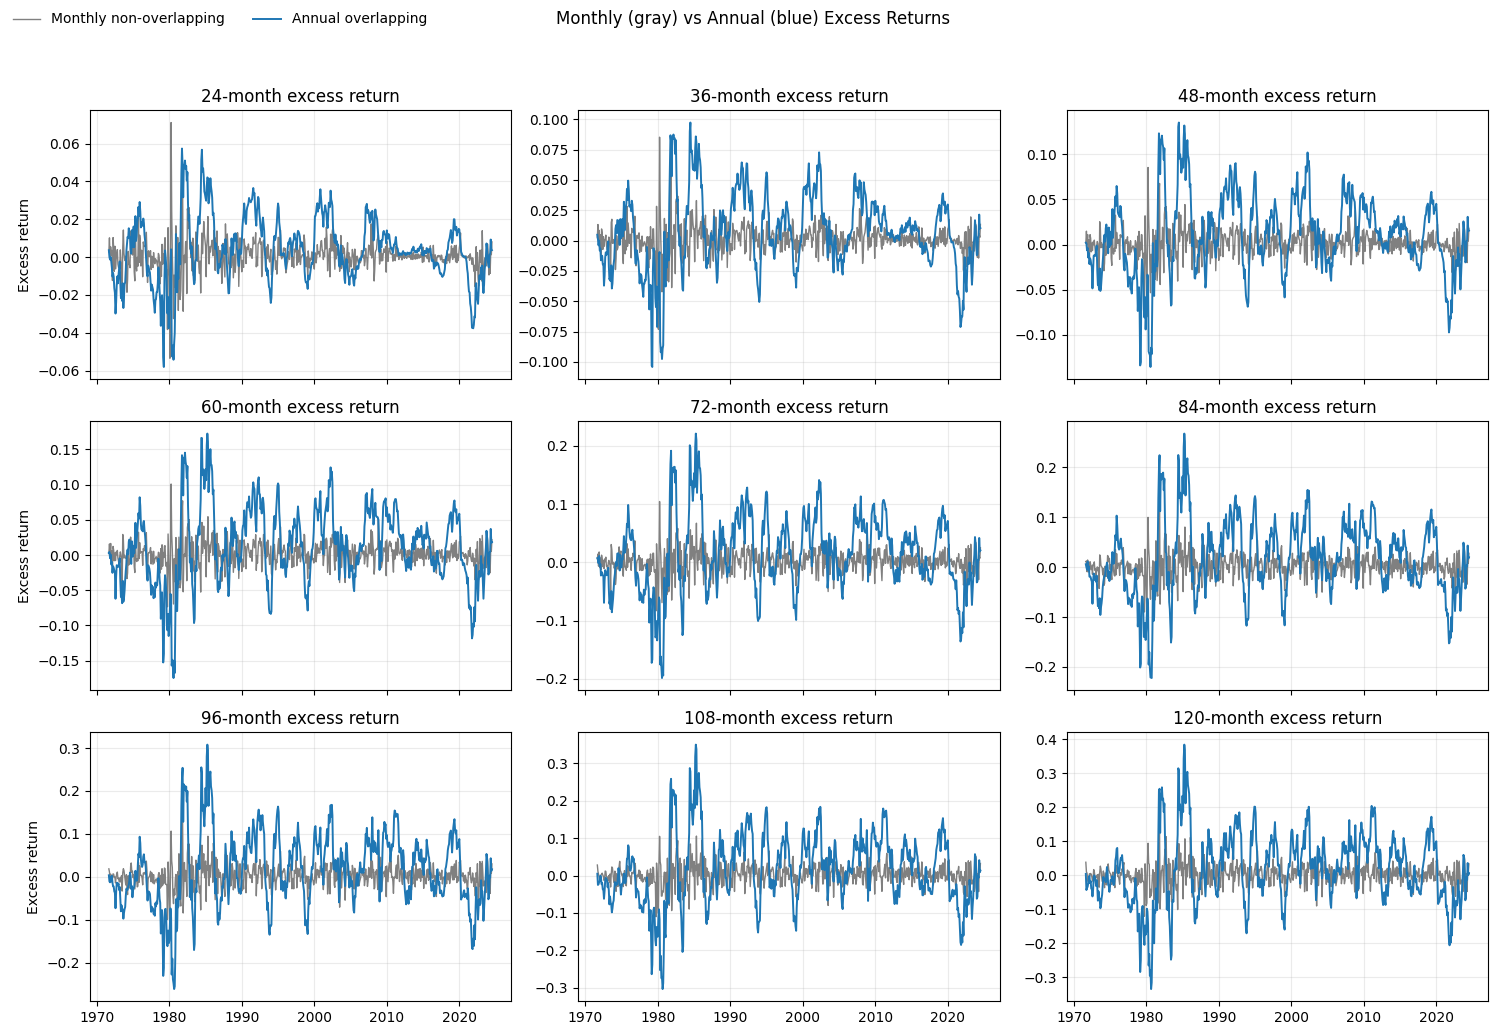

In [10]:
import matplotlib.pyplot as plt

ncols, nrows = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10), sharex=True)
axes = axes.flatten()

# Use the same maturities as annual xr, but keep only those also present in monthly_xr
cols = [c for c in list(xr.columns)[-nrows * ncols:] if c in monthly_xr.columns]

# Align dates to common index for clean overlays
common_idx = xr.index.intersection(monthly_xr.index)

for i, col in enumerate(cols):
    ax = axes[i]
    ax.plot(
        common_idx, monthly_xr.loc[common_idx, col],
        color="gray", linewidth=1.0,
        label="Monthly non-overlapping" if i == 0 else None
    )
    ax.plot(
        common_idx, xr.loc[common_idx, col], linestyle="-", linewidth=1.4,
        label="Annual overlapping" if i == 0 else None
    )
    ax.set_title(f"{col}-month excess return")
    ax.set_xlabel("")
    ax.grid(alpha=0.25)
    ax.set_ylabel("Excess return" if i % ncols == 0 else "")

# Hide unused axes
for j in range(len(cols), len(axes)):
    axes[j].axis("off")

# Single legend for whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=2, frameon=False)

fig.suptitle("Monthly (gray) vs Annual (blue) Excess Returns", y=1.03)
plt.tight_layout()
plt.show()